##### Classical SVM Implementation - Spambase - SelectKBest

In [1]:
# =============================================================================
# SECTION 1: IMPORTS
# =============================================================================
# --- Import Libraries ---
import pandas as pd
import numpy as np
import time
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, accuracy_score, 
                             confusion_matrix, precision_score, 
                             recall_score, f1_score, balanced_accuracy_score)
from sklearn.feature_selection import VarianceThreshold

import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

In [2]:
# --- Import Spambase Column Names ---
spambase_columns = [
    "word_freq_make",
    "word_freq_address",
    "word_freq_all",
    "word_freq_3d",
    "word_freq_our",
    "word_freq_over",
    "word_freq_remove",
    "word_freq_internet",
    "word_freq_order",
    "word_freq_mail",
    "word_freq_receive",
    "word_freq_will",
    "word_freq_people",
    "word_freq_report",
    "word_freq_addresses",
    "word_freq_free",
    "word_freq_business",
    "word_freq_email",
    "word_freq_you",
    "word_freq_credit",
    "word_freq_your",
    "word_freq_font",
    "word_freq_000",
    "word_freq_money",
    "word_freq_hp",
    "word_freq_hpl",
    "word_freq_george",
    "word_freq_650",
    "word_freq_lab",
    "word_freq_labs",
    "word_freq_telnet",
    "word_freq_857",
    "word_freq_data",
    "word_freq_415",
    "word_freq_85",
    "word_freq_technology",
    "word_freq_1999",
    "word_freq_parts",
    "word_freq_pm",
    "word_freq_direct",
    "word_freq_cs",
    "word_freq_meeting",
    "word_freq_original",
    "word_freq_project",
    "word_freq_re",
    "word_freq_edu",
    "word_freq_table",
    "word_freq_conference",
    "char_freq_;",
    "char_freq_(",
    "char_freq_[",
    "char_freq_!",
    "char_freq_$",
    "char_freq_#",
    "capital_run_length_average",
    "capital_run_length_longest",
    "capital_run_length_total",
    # finally the target label column:
    "label"
]

# Load data
file_path = r'C:\Users\User\Documents\MyProjects\FYP_ResearchProject\data\spambase\spambase.data'
df = pd.read_csv(file_path, header=None, names=spambase_columns)

# Drop duplicates
print(f"Original shape of Spambase data: {df.shape}") # Prints original dataset shape
df.drop_duplicates(inplace=True) # Remove duplicates
print(f"Shape after dropping duplicates: {df.shape}\n") # Then print again the new shape

Original shape of Spambase data: (4601, 58)
Shape after dropping duplicates: (4210, 58)



In [ ]:
# ================================================================================
# CELL 6: Experiment Configurations (FULL COMBINATORIAL GRID)
# ================================================================================


# ==========================================
# EXPERIMENT CONFIGURATIONS
# ==========================================


# Define parameter ranges
sample_sizes = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
n_features_range = [2, 3, 4, 5, 6, 7, 8]  
kernels = ['linear', 'rbf']


# Generate all combinations programmatically
experiments = []
exp_id = 1


for samples in sample_sizes:
    for n_feat in n_features_range:  
        for kernel in kernels:
            experiments.append({
                'id': f'Exp{exp_id:03d}_{samples}samp_{n_feat}feat_{kernel}',  
                'samples': samples,
                'n_features': n_feat,  # CHANGED: key name
                'kernel': kernel
            })
            exp_id += 1


print(f"Total experiments configured: {len(experiments)}")
print(f"Parameter Grid:")
print(f"  - Sample Sizes: {sample_sizes}")
print(f"  - Number of Features: {n_features_range}")  
print(f"  - Kernels: {kernels}")
print(f"  - Total Combinations: {len(sample_sizes)} × {len(n_features_range)} × {len(kernels)} = {len(experiments)}")  
print(f"\n Warning: This will take a LONG time to run!")
print(f"   Estimated time: ~{len(experiments) * 0.1:.0f} minutes\n")

print("Preview of first 5 experiments:")
for exp in experiments[:5]:
    print(f"  {exp['id']}: samples={exp['samples']}, n_features={exp['n_features']}, kernel={exp['kernel']}")  


Total experiments configured: 140
Parameter Grid:
  - Sample Sizes: [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
  - Number of Features: [2, 3, 4, 5, 6, 7, 8]
  - Kernels: ['linear', 'rbf']
  - Total Combinations: 10 × 7 × 2 = 140

   Estimated time: ~14 minutes

Preview of first 5 experiments:
  Exp001_100samp_2feat_linear: samples=100, n_features=2, kernel=linear
  Exp002_100samp_2feat_rbf: samples=100, n_features=2, kernel=rbf
  Exp003_100samp_3feat_linear: samples=100, n_features=3, kernel=linear
  Exp004_100samp_3feat_rbf: samples=100, n_features=3, kernel=rbf
  Exp005_100samp_4feat_linear: samples=100, n_features=4, kernel=linear


##### Main Experiment Loop

In [ ]:
# ================================================================================
# CELL 8: Main Experiment Loop
# ================================================================================

# ===================================================================
# MAIN EXPERIMENT LOOP
# ===================================================================


all_results = []


for exp_num, config in enumerate(experiments, 1):
    print("\n" + "="*80)
    print(f"EXPERIMENT {exp_num}/{len(experiments)}: {config['id']}")
    print("="*80)
    print(f" Samples: {config['samples']}")
    print(f" Number of Features: {config['n_features']}")  
    print("="*80)


    # ===================================================================
    # 1. DATA PREPARATION
    # ===================================================================
    
    X = df.drop('label', axis=1)
    y = df['label']


    subset_size = int(round(config['samples'] / 0.7))
    
    X_subset, _, y_subset, _ = train_test_split(
        X, y,
        train_size=subset_size,
        stratify=y,
        random_state=42
    )


    X_train, X_test, y_train, y_test = train_test_split(
        X_subset, y_subset,
        train_size=0.70,
        random_state=42,
        stratify=y_subset
    )


    print(f"\nDataset created: {X_train.shape[0]} train, {X_test.shape[0]} test")


    # ===================================================================
    # 2. SCALING
    # ===================================================================
    
    selector_variance = VarianceThreshold(threshold=0)
    X_train_filtered = selector_variance.fit_transform(X_train)
    X_test_filtered = selector_variance.transform(X_test)
    remaining_cols = X_train.columns[selector_variance.get_support()]


    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_filtered)
    X_test_scaled = scaler.transform(X_test_filtered)
    X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=remaining_cols)
    X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=remaining_cols)


    print("Data scaled successfully")


    # ===================================================================
    # 3. CORRELATION-BASED FEATURE DROPPING
    # ===================================================================
    
    THRESH = 0.9
    corr_matrix_train = X_train_scaled_df.corr().abs()
    upper_triangle = corr_matrix_train.where(
        np.triu(np.ones(corr_matrix_train.shape), k=1).astype(bool)
    )


    columns_to_drop = set()
    for column in upper_triangle.columns:
        high_corr_partners = upper_triangle.index[upper_triangle[column] > THRESH].tolist()
        if high_corr_partners:
            for partner in high_corr_partners:
                corr_main_vs_target = y_train.corr(X_train_scaled_df[column])
                corr_partner_vs_target = y_train.corr(X_train_scaled_df[partner])


                if abs(corr_main_vs_target) < abs(corr_partner_vs_target):
                    columns_to_drop.add(column)
                else:
                    columns_to_drop.add(partner)


    to_drop_final = sorted(list(columns_to_drop))
    X_train_selected = X_train_scaled_df.drop(columns=to_drop_final)
    X_test_selected = X_test_scaled_df.drop(columns=to_drop_final)


    print(f"Dropped {len(to_drop_final)} highly correlated features")


    # ===================================================================
    # 4. K-BEST FEATURE SELECTION (CHANGED FROM PERCENTILE)
    # ===================================================================
    
    k_features = config['n_features']  
    selector = SelectKBest(score_func=mutual_info_classif, k=k_features)  
    X_train_final = selector.fit_transform(X_train_selected, y_train)
    X_test_final = selector.transform(X_test_selected)


    selected_features = X_train_selected.columns[selector.get_support()].tolist()
    n_features_selected = len(selected_features)  
    
    print(f"SelectKBest: Selected {n_features_selected} features (k={k_features})")  
    print(f"Selected features: {selected_features}")


    # ===================================================================
    # 5. GRID SEARCH FOR OPTIMAL C AND GAMMA
    # ===================================================================
    
    kernel_type = config['kernel']  # Get kernel from config
    print(f"\nGrid searching for optimal hyperparameters (Kernel: {kernel_type.upper()})...")
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


    # Build parameter grid based on kernel type
    if kernel_type == 'rbf':
        param_grid = {
            'C': [0.001, 0.01, 0.1, 1, 10, 100],
            'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1]
        }
        svm_model = SVC(kernel='rbf', random_state=42)
    else:  # linear
        param_grid = {
            'C': [0.001, 0.01, 0.1, 1, 10, 100]
        }
        svm_model = SVC(kernel='linear', random_state=42)
    
    grid_search = GridSearchCV(
        svm_model,
        param_grid,
        cv=cv,
        scoring='accuracy',
        verbose=0,
        n_jobs=-1
    )


    start_train = time.time()
    grid_search.fit(X_train_final, y_train)
    train_time = time.time() - start_train


    best_model = grid_search.best_estimator_
    best_params = grid_search.best_params_
    best_c = best_params['C']
    best_gamma = best_params.get('gamma', None)  # None for linear kernel
    cv_score = grid_search.best_score_


    print(f" → Best C: {best_c}")
    if best_gamma is not None:
        print(f" → Best Gamma: {best_gamma}")
    print(f" → CV Score: {cv_score:.4f}")
    print(f" → Training time: {train_time:.2f}s")
    
    # ===================================================================
    # 6. EVALUATION
    # ===================================================================
    
    y_train_pred = best_model.predict(X_train_final)
    y_test_pred = best_model.predict(X_test_final)


    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    test_balanced_acc = balanced_accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred, zero_division=0)
    recall = recall_score(y_test, y_test_pred, zero_division=0)
    f1 = f1_score(y_test, y_test_pred, zero_division=0)
    gen_gap = abs(train_acc - test_acc)


    print(f"\n --- Model Performance ---")
    print(f" → Train Accuracy: {train_acc:.4f}")
    print(f" → Test Accuracy: {test_acc:.4f}")
    print(f" → Test Balanced Accuracy: {test_balanced_acc:.4f}")
    print(f" → Precision: {precision:.4f}")
    print(f" → Recall: {recall:.4f}")
    print(f" → F1-Score: {f1:.4f}")
    print(f" → Generalization Gap: {gen_gap:.4f}")
    
    # Print detailed classification report
    print("\n --- Classification Report ---")
    print(classification_report(y_test, y_test_pred, 
                                target_names=['Non-Spam', 'Spam'], 
                                zero_division=0))


    # ===================================================================
    # 7. STORE RESULTS
    # ===================================================================
    
    all_results.append({
        'experiment_id': config['id'],
        'exp_number': exp_num,
        'samples': config['samples'],
        'n_features': k_features,  
        'n_features_selected': n_features_selected,  
        'kernel': kernel_type,
        'selected_features': selected_features,
        'best_c': best_c,
        'best_gamma': best_gamma,
        'cv_score': cv_score,
        'train_acc': train_acc,
        'test_acc': test_acc,
        'test_balanced_acc': test_balanced_acc,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'gen_gap': gen_gap,
        'train_time': train_time,
        'y_test': y_test.tolist(),
        'y_pred': y_test_pred.tolist()
    })



print("\n" + "="*80)
print("ALL EXPERIMENTS COMPLETE!")
print("="*80)



EXPERIMENT 1/140: Exp001_100samp_2feat_linear
 Samples: 100
 Number of Features: 2

Dataset created: 100 train, 43 test
Data scaled successfully
Dropped 4 highly correlated features
SelectKBest: Selected 2 features (k=2)
Selected features: ['word_freq_remove', 'word_freq_your']

Grid searching for optimal hyperparameters (Kernel: LINEAR)...
 → Best C: 10
 → CV Score: 0.8600
 → Training time: 5.78s

 --- Model Performance ---
 → Train Accuracy: 0.8600
 → Test Accuracy: 0.8140
 → Test Balanced Accuracy: 0.7851
 → Precision: 0.8462
 → Recall: 0.6471
 → F1-Score: 0.7333
 → Generalization Gap: 0.0460

 --- Classification Report ---
              precision    recall  f1-score   support

    Non-Spam       0.80      0.92      0.86        26
        Spam       0.85      0.65      0.73        17

    accuracy                           0.81        43
   macro avg       0.82      0.79      0.80        43
weighted avg       0.82      0.81      0.81        43


EXPERIMENT 2/140: Exp002_100samp_2fe

##### Results Analysis and Visualization

In [5]:
# ================================================================================
# CELL 10: Results Summary
# ================================================================================


# Convert results to DataFrame
results_df = pd.DataFrame(all_results)
print("\nExperiment Results Summary:")
print(results_df[['experiment_id', 'samples', 'n_features', 'n_features_selected', 'train_acc', 'test_acc', 'precision', 'recall', 'f1_score', 'gen_gap']].to_string(index=False))

# Save results
results_df.to_csv('classical_svm_feature_selection_results.csv', index=False)
print("\nResults saved to: classical_svm_feature_selection_results.csv")



Experiment Results Summary:
               experiment_id  samples  n_features  n_features_selected  train_acc  test_acc  precision   recall  f1_score  gen_gap
 Exp001_100samp_2feat_linear      100           2                    2   0.860000  0.813953   0.846154 0.647059  0.733333 0.046047
    Exp002_100samp_2feat_rbf      100           2                    2   0.860000  0.813953   0.846154 0.647059  0.733333 0.046047
 Exp003_100samp_3feat_linear      100           3                    3   0.800000  0.790698   0.785714 0.647059  0.709677 0.009302
    Exp004_100samp_3feat_rbf      100           3                    3   0.790000  0.813953   0.846154 0.647059  0.733333 0.023953
 Exp005_100samp_4feat_linear      100           4                    4   0.900000  0.883721   0.928571 0.764706  0.838710 0.016279
    Exp006_100samp_4feat_rbf      100           4                    4   0.930000  0.906977   0.933333 0.823529  0.875000 0.023023
 Exp007_100samp_5feat_linear      100           5     

In [6]:
# ================================================================================
# CELL 11: Best Configurations
# ================================================================================


# Separate data by kernel
rbf_data = results_df[results_df['kernel'] == 'rbf'].copy()
linear_data = results_df[results_df['kernel'] == 'linear'].copy()


# Find best configurations
best_rbf_idx = rbf_data['test_acc'].idxmax()
best_rbf = rbf_data.loc[best_rbf_idx]


best_linear_idx = linear_data['test_acc'].idxmax()
best_linear = linear_data.loc[best_linear_idx]


print("\n" + "="*80)
print("BEST CONFIGURATIONS")
print("="*80)


# ==============================================================================
# RBF KERNEL (PRIMARY - FOR QSVM COMPARISON)
# ==============================================================================
print("\n" + "─"*80)
print("RBF KERNEL (Primary Configuration for QSVM)")
print("─"*80)


print(f"\nExperiment ID: {best_rbf['experiment_id']}")
print(f"  → Train Accuracy: {best_rbf['train_acc']:.4f}")
print(f"  → Test Accuracy: {best_rbf['test_acc']:.4f}")
print(f"  → Precision: {best_rbf['precision']:.4f}")
print(f"  → Recall: {best_rbf['recall']:.4f}")
print(f"  → F1-Score: {best_rbf['f1_score']:.4f}")
print(f"  → Generalization Gap: {best_rbf['gen_gap']:.4f}")
print(f"\nConfiguration:")
print(f"  → Samples: {int(best_rbf['samples'])}")
print(f"  → Number of Features (k): {int(best_rbf['n_features'])}")
print(f"  → Best C: {best_rbf['best_c']}")
print(f"  → Best Gamma: {best_rbf['best_gamma']}")
print(f"\nSelected Features:")
for i, feat in enumerate(best_rbf['selected_features'], 1):
    print(f"  {i}. {feat}")


# ==============================================================================
# LINEAR KERNEL (BASELINE)
# ==============================================================================
print("\n" + "─"*80)
print("LINEAR KERNEL (Baseline)")
print("─"*80)


print(f"\nExperiment ID: {best_linear['experiment_id']}")
print(f"  → Train Accuracy: {best_linear['train_acc']:.4f}")
print(f"  → Test Accuracy: {best_linear['test_acc']:.4f}")
print(f"  → Precision: {best_linear['precision']:.4f}")
print(f"  → Recall: {best_linear['recall']:.4f}")
print(f"  → F1-Score: {best_linear['f1_score']:.4f}")
print(f"  → Generalization Gap: {best_linear['gen_gap']:.4f}")
print(f"\nConfiguration:")
print(f"  → Samples: {int(best_linear['samples'])}")
print(f"  → Number of Features (k): {int(best_linear['n_features'])}")
print(f"  → Best C: {best_linear['best_c']}")
print(f"\nSelected Features:")
for i, feat in enumerate(best_linear['selected_features'], 1):
    print(f"  {i}. {feat}")


# ==============================================================================
# COMPARISON
# ==============================================================================
print("\n" + "="*80)
print("KERNEL COMPARISON")
print("="*80)


comparison_data = {
    'Metric': ['Train Accuracy', 'Test Accuracy', 'Precision', 'Recall', 'F1-Score', 'Gen Gap', 'Features (k)'],
    'RBF (Primary)': [
        f"{best_rbf['train_acc']:.4f}",
        f"{best_rbf['test_acc']:.4f}",
        f"{best_rbf['precision']:.4f}",
        f"{best_rbf['recall']:.4f}",
        f"{best_rbf['f1_score']:.4f}",
        f"{best_rbf['gen_gap']:.4f}",
        f"{int(best_rbf['n_features'])}"
    ],
    'Linear (Baseline)': [
        f"{best_linear['train_acc']:.4f}",
        f"{best_linear['test_acc']:.4f}",
        f"{best_linear['precision']:.4f}",
        f"{best_linear['recall']:.4f}",
        f"{best_linear['f1_score']:.4f}",
        f"{best_linear['gen_gap']:.4f}",
        f"{int(best_linear['n_features'])}"
    ]
}


comparison_df = pd.DataFrame(comparison_data)
print("\n" + comparison_df.to_string(index=False))


# ==============================================================================
# QSVM CONFIGURATION EXPORT
# ==============================================================================
print(f"\n{'='*80}")
print(f"CONFIGURATION FOR QUANTUM SVM")
print(f"{'='*80}")
print(f"\nClassical RBF Benchmark:")
print(f"  → Accuracy: {best_rbf['test_acc']:.4f}")
print(f"  → Recall: {best_rbf['recall']:.4f}")
print(f"  → F1-Score: {best_rbf['f1_score']:.4f}")
print(f"\nParameters to Transfer to QSVM:")
print(f"  → Number of Qubits: {int(best_rbf['n_features'])}")
print(f"  → Training Samples: {int(best_rbf['samples'])}")
print(f"  → Optimal C: {best_rbf['best_c']}")
print(f"  → Optimal Gamma: {best_rbf['best_gamma']}")
print(f"  → Selected Features: {best_rbf['selected_features']}")
print(f"\nBaseline Comparison (Linear SVM):")
print(f"  → Accuracy: {best_linear['test_acc']:.4f}")
print(f"  → Purpose: Demonstrates non-linear advantage")
print(f"{'='*80}\n")


# ==============================================================================
# EXPORT CONFIGURATION FOR QSVM EXPERIMENT
# ==============================================================================
qsvm_config = {
    'n_qubits': int(best_rbf['n_features']),
    'n_samples': int(best_rbf['samples']),
    'selected_features': best_rbf['selected_features'],
    'optimal_C': best_rbf['best_c'],
    'optimal_gamma': best_rbf['best_gamma'],
    'classical_rbf_train_accuracy': best_rbf['train_acc'],
    'classical_rbf_accuracy': best_rbf['test_acc'],
    'classical_rbf_recall': best_rbf['recall'],
    'classical_rbf_f1': best_rbf['f1_score'],
    'baseline_linear_accuracy': best_linear['test_acc']
}


# Save for QSVM experiment
import json
with open('qsvm_configuration.json', 'w') as f:
    json.dump(qsvm_config, f, indent=4)


print("✓ QSVM configuration saved to: qsvm_configuration.json")



BEST CONFIGURATIONS

────────────────────────────────────────────────────────────────────────────────
RBF KERNEL (Primary Configuration for QSVM)
────────────────────────────────────────────────────────────────────────────────

Experiment ID: Exp032_300samp_3feat_rbf
  → Train Accuracy: 0.8967
  → Test Accuracy: 0.9380
  → Precision: 0.9574
  → Recall: 0.8824
  → F1-Score: 0.9184
  → Generalization Gap: 0.0413

Configuration:
  → Samples: 300
  → Number of Features (k): 3
  → Best C: 1.0
  → Best Gamma: auto

Selected Features:
  1. word_freq_remove
  2. char_freq_!
  3. char_freq_$

────────────────────────────────────────────────────────────────────────────────
LINEAR KERNEL (Baseline)
────────────────────────────────────────────────────────────────────────────────

Experiment ID: Exp047_400samp_4feat_linear
  → Train Accuracy: 0.8922
  → Test Accuracy: 0.9419
  → Precision: 0.9836
  → Recall: 0.8696
  → F1-Score: 0.9231
  → Generalization Gap: 0.0496

Configuration:
  → Samples: 40

Generating confusion matrices...



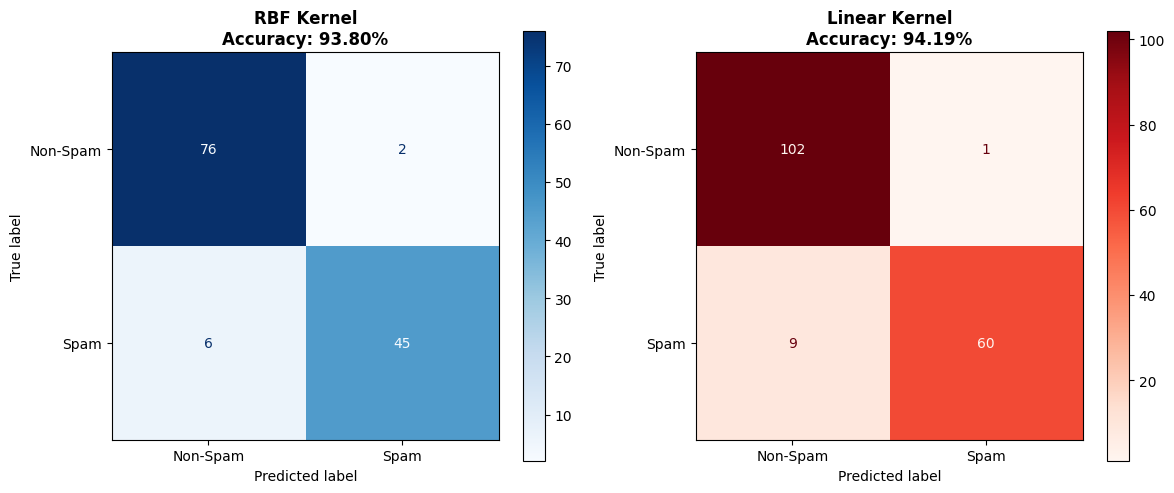

✓ Confusion matrices generated successfully


In [7]:
# ================================================================================
# CELL 11b: Confusion Matrices (SIMPLER VERSION)
# ================================================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("Generating confusion matrices...\n")

# Simply extract the stored predictions - NO RECONSTRUCTION NEEDED!
y_test_rbf = np.array(best_rbf['y_test'])
y_pred_rbf = np.array(best_rbf['y_pred'])

y_test_linear = np.array(best_linear['y_test'])
y_pred_linear = np.array(best_linear['y_pred'])

# Create confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_rbf = confusion_matrix(y_test_rbf, y_pred_rbf)
disp_rbf = ConfusionMatrixDisplay(confusion_matrix=cm_rbf, 
                                   display_labels=['Non-Spam', 'Spam'])
disp_rbf.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title(f'RBF Kernel\nAccuracy: {best_rbf["test_acc"]:.2%}', 
                 fontsize=12, fontweight='bold')

cm_linear = confusion_matrix(y_test_linear, y_pred_linear)
disp_linear = ConfusionMatrixDisplay(confusion_matrix=cm_linear, 
                                      display_labels=['Non-Spam', 'Spam'])
disp_linear.plot(ax=axes[1], cmap='Reds', values_format='d')
axes[1].set_title(f'Linear Kernel\nAccuracy: {best_linear["test_acc"]:.2%}', 
                 fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Confusion matrices generated successfully")



CLASSICAL SVM PERFORMANCE ANALYSIS

--- Plotting: Effect of Sample Size ---


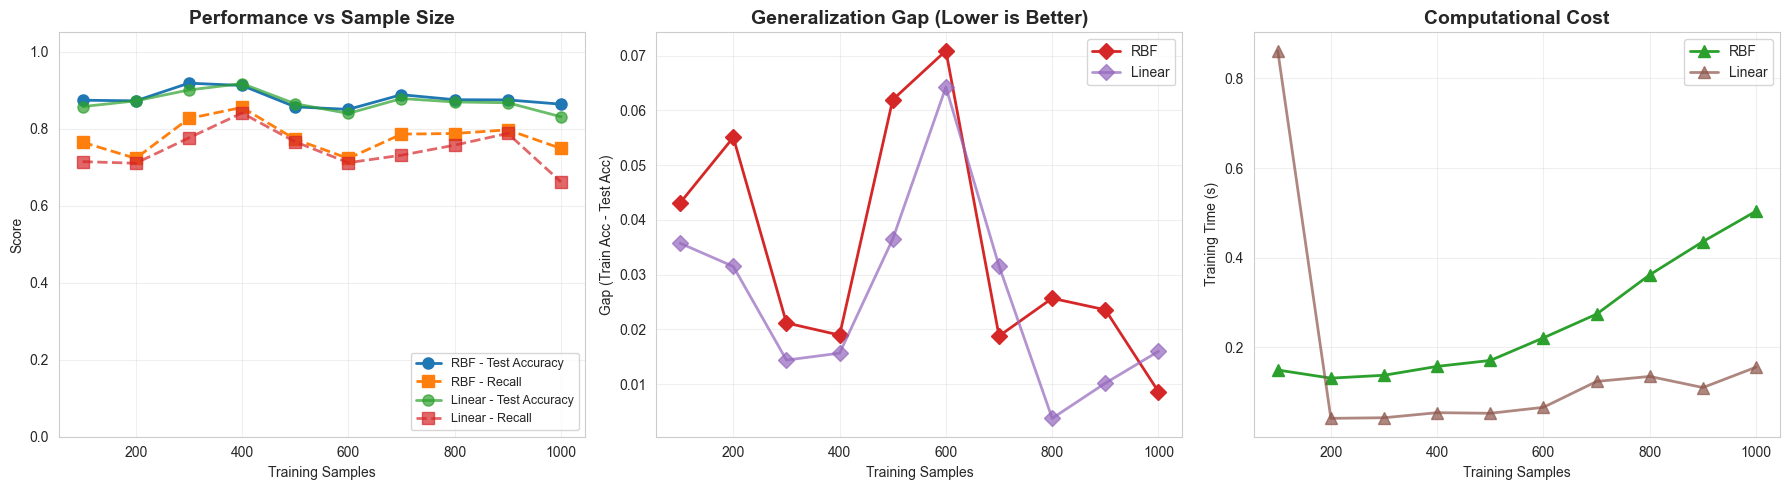


--- Plotting: Effect of Feature Count ---


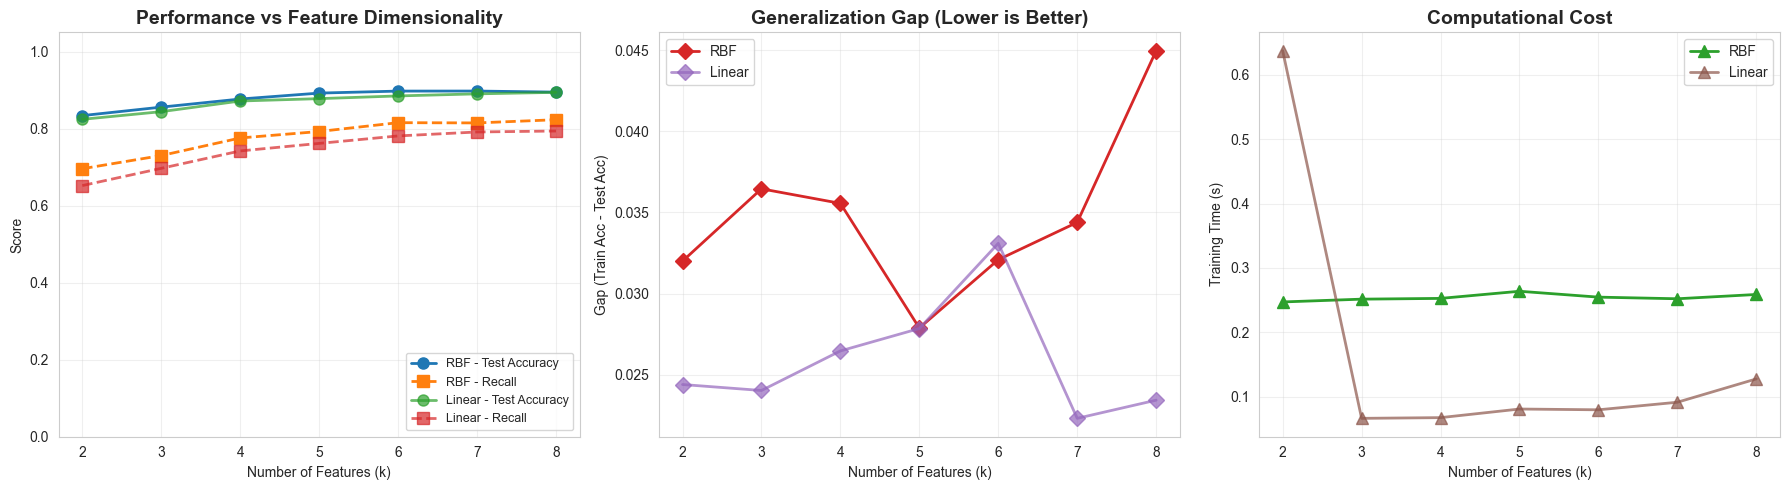


--- Plotting: RBF Performance Heatmap ---


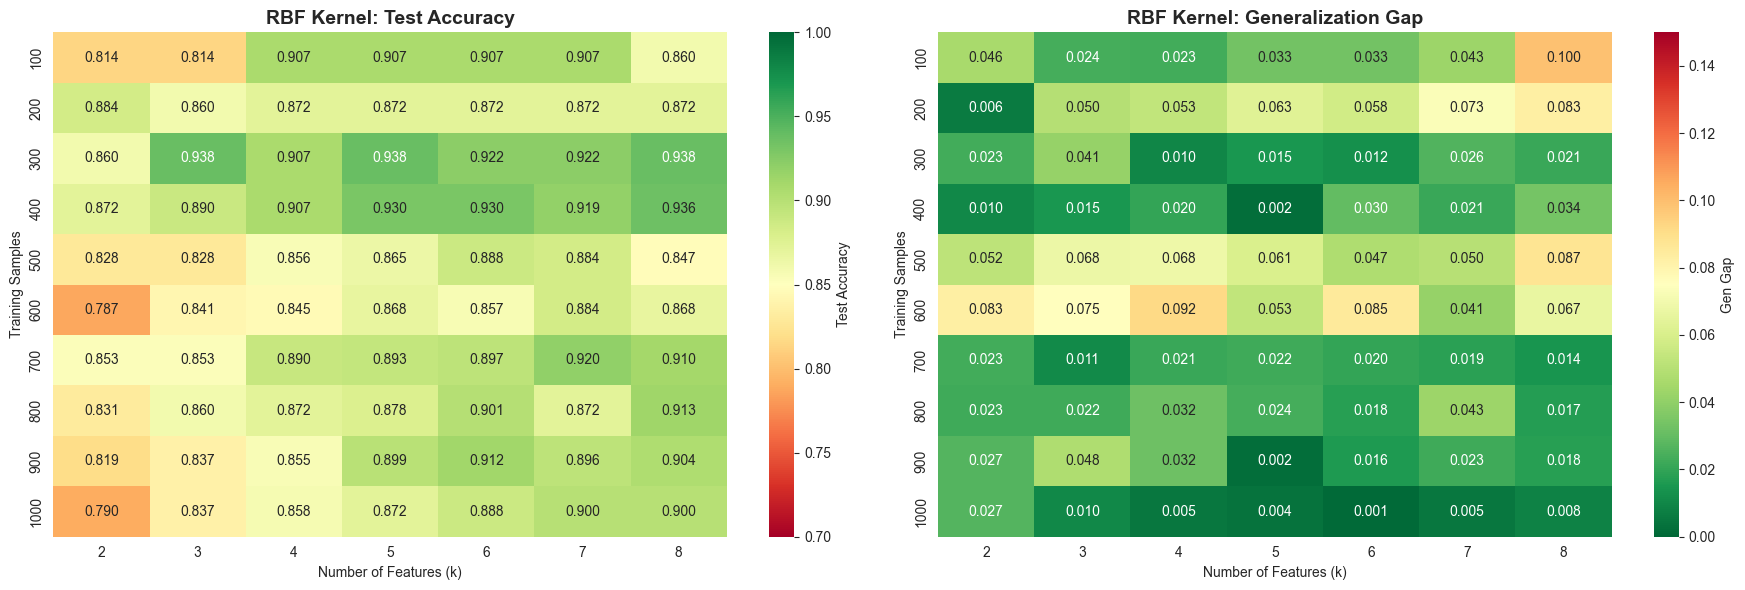


--- Plotting: Linear Performance Heatmap ---


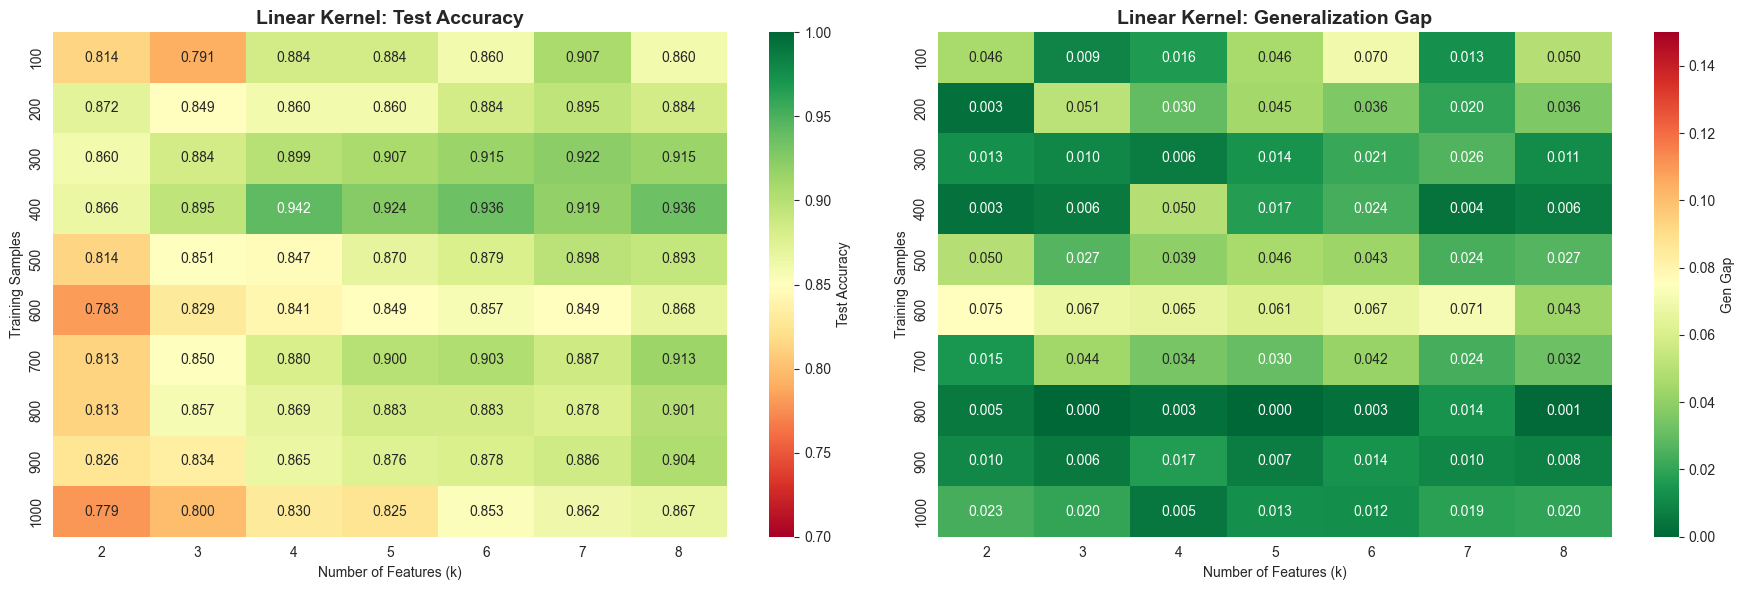


--- Plotting: Best Configs Comparison ---


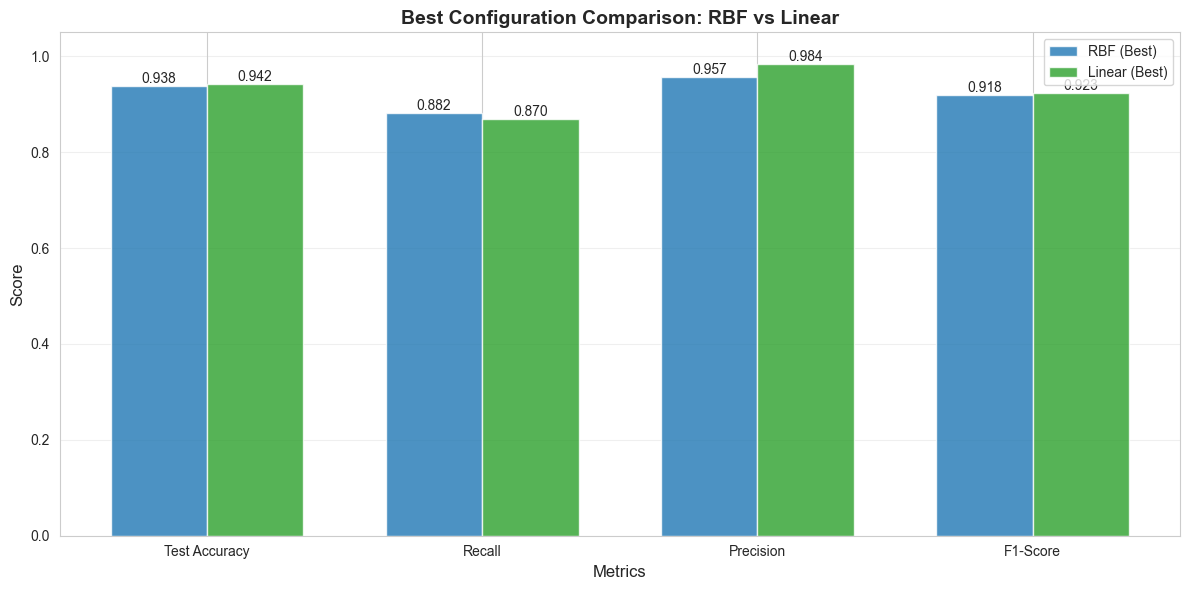


VISUALIZATION COMPLETE!


In [8]:
# ================================================================================
# CELL 12: Performance Analysis Visualizations
# ================================================================================


import matplotlib.pyplot as plt
import seaborn as sns


# ==========================================
# CONFIGURATION & STYLE
# ==========================================
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (18, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['lines.markersize'] = 8


def plot_classical_svm_analysis(df):
    """
    Generates standardized visualizations for Classical SVM experiments.
    Compares RBF vs Linear kernels across different configurations.
    """
    
    print("\n" + "="*80)
    print("CLASSICAL SVM PERFORMANCE ANALYSIS")
    print("="*80)
    
    # Separate by kernel
    rbf_df = df[df['kernel'] == 'rbf'].copy()
    linear_df = df[df['kernel'] == 'linear'].copy()
    
    # ===================================================================
    # PLOT 1: SAMPLE SIZE EFFECT
    # ===================================================================
    print("\n--- Plotting: Effect of Sample Size ---")
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Group by samples and get mean
    rbf_samples = rbf_df.groupby('samples').agg({
        'test_acc': 'mean',
        'recall': 'mean',
        'gen_gap': 'mean',
        'train_time': 'mean'
    }).reset_index()
    
    linear_samples = linear_df.groupby('samples').agg({
        'test_acc': 'mean',
        'recall': 'mean',
        'gen_gap': 'mean',
        'train_time': 'mean'
    }).reset_index()
    
    # Subplot 1: Performance
    axes[0].plot(rbf_samples['samples'], rbf_samples['test_acc'], 'o-', 
                 label='RBF - Test Accuracy', color='#1f77b4', linewidth=2)
    axes[0].plot(rbf_samples['samples'], rbf_samples['recall'], 's--', 
                 label='RBF - Recall', color='#ff7f0e', linewidth=2)
    axes[0].plot(linear_samples['samples'], linear_samples['test_acc'], 'o-', 
                 label='Linear - Test Accuracy', color='#2ca02c', linewidth=2, alpha=0.7)
    axes[0].plot(linear_samples['samples'], linear_samples['recall'], 's--', 
                 label='Linear - Recall', color='#d62728', linewidth=2, alpha=0.7)
    axes[0].set_xlabel('Training Samples')
    axes[0].set_ylabel('Score')
    axes[0].set_title('Performance vs Sample Size')
    axes[0].set_ylim(0, 1.05)
    axes[0].legend(loc='lower right', fontsize=9)
    axes[0].grid(True, alpha=0.3)
    
    # Subplot 2: Generalization Gap
    axes[1].plot(rbf_samples['samples'], rbf_samples['gen_gap'], 'D-', 
                 label='RBF', color='#d62728', linewidth=2)
    axes[1].plot(linear_samples['samples'], linear_samples['gen_gap'], 'D-', 
                 label='Linear', color='#9467bd', linewidth=2, alpha=0.7)
    axes[1].set_xlabel('Training Samples')
    axes[1].set_ylabel('Gap (Train Acc - Test Acc)')
    axes[1].set_title('Generalization Gap (Lower is Better)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Subplot 3: Training Time
    axes[2].plot(rbf_samples['samples'], rbf_samples['train_time'], '^-', 
                 label='RBF', color='#2ca02c', linewidth=2)
    axes[2].plot(linear_samples['samples'], linear_samples['train_time'], '^-', 
                 label='Linear', color='#8c564b', linewidth=2, alpha=0.7)
    axes[2].set_xlabel('Training Samples')
    axes[2].set_ylabel('Training Time (s)')
    axes[2].set_title('Computational Cost')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # ===================================================================
    # PLOT 2: FEATURE DIMENSIONALITY EFFECT
    # ===================================================================
    print("\n--- Plotting: Effect of Feature Count ---")
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Group by n_features
    rbf_features = rbf_df.groupby('n_features').agg({
        'test_acc': 'mean',
        'recall': 'mean',
        'gen_gap': 'mean',
        'train_time': 'mean'
    }).reset_index()
    
    linear_features = linear_df.groupby('n_features').agg({
        'test_acc': 'mean',
        'recall': 'mean',
        'gen_gap': 'mean',
        'train_time': 'mean'
    }).reset_index()
    
    # Subplot 1: Performance
    axes[0].plot(rbf_features['n_features'], rbf_features['test_acc'], 'o-', 
                 label='RBF - Test Accuracy', color='#1f77b4', linewidth=2)
    axes[0].plot(rbf_features['n_features'], rbf_features['recall'], 's--', 
                 label='RBF - Recall', color='#ff7f0e', linewidth=2)
    axes[0].plot(linear_features['n_features'], linear_features['test_acc'], 'o-', 
                 label='Linear - Test Accuracy', color='#2ca02c', linewidth=2, alpha=0.7)
    axes[0].plot(linear_features['n_features'], linear_features['recall'], 's--', 
                 label='Linear - Recall', color='#d62728', linewidth=2, alpha=0.7)
    axes[0].set_xlabel('Number of Features (k)')
    axes[0].set_ylabel('Score')
    axes[0].set_title('Performance vs Feature Dimensionality')
    axes[0].set_ylim(0, 1.05)
    axes[0].legend(loc='lower right', fontsize=9)
    axes[0].grid(True, alpha=0.3)
    
    # Subplot 2: Generalization Gap
    axes[1].plot(rbf_features['n_features'], rbf_features['gen_gap'], 'D-', 
                 label='RBF', color='#d62728', linewidth=2)
    axes[1].plot(linear_features['n_features'], linear_features['gen_gap'], 'D-', 
                 label='Linear', color='#9467bd', linewidth=2, alpha=0.7)
    axes[1].set_xlabel('Number of Features (k)')
    axes[1].set_ylabel('Gap (Train Acc - Test Acc)')
    axes[1].set_title('Generalization Gap (Lower is Better)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Subplot 3: Training Time
    axes[2].plot(rbf_features['n_features'], rbf_features['train_time'], '^-', 
                 label='RBF', color='#2ca02c', linewidth=2)
    axes[2].plot(linear_features['n_features'], linear_features['train_time'], '^-', 
                 label='Linear', color='#8c564b', linewidth=2, alpha=0.7)
    axes[2].set_xlabel('Number of Features (k)')
    axes[2].set_ylabel('Training Time (s)')
    axes[2].set_title('Computational Cost')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # ===================================================================
    # PLOT 3: BEST CONFIGURATION HEATMAP (RBF ONLY)
    # ===================================================================
    print("\n--- Plotting: RBF Performance Heatmap ---")
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # Create pivot tables for heatmaps
    pivot_rbf_acc = rbf_df.pivot_table(
        values='test_acc', 
        index='samples', 
        columns='n_features'
    )
    
    pivot_rbf_gap = rbf_df.pivot_table(
        values='gen_gap', 
        index='samples', 
        columns='n_features'
    )
    
    # Heatmap 1: Test Accuracy
    sns.heatmap(pivot_rbf_acc, annot=True, fmt='.3f', cmap='RdYlGn', 
                ax=axes[0], vmin=0.7, vmax=1.0, cbar_kws={'label': 'Test Accuracy'})
    axes[0].set_title('RBF Kernel: Test Accuracy', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Number of Features (k)')
    axes[0].set_ylabel('Training Samples')
    
    # Heatmap 2: Generalization Gap
    sns.heatmap(pivot_rbf_gap, annot=True, fmt='.3f', cmap='RdYlGn_r', 
                ax=axes[1], vmin=0, vmax=0.15, cbar_kws={'label': 'Gen Gap'})
    axes[1].set_title('RBF Kernel: Generalization Gap', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Number of Features (k)')
    axes[1].set_ylabel('Training Samples')
    
    plt.tight_layout()
    plt.show()
    
    # ===================================================================
    # PLOT 4: LINEAR PERFORMANCE HEATMAP
    # ===================================================================
    print("\n--- Plotting: Linear Performance Heatmap ---")
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # Create pivot tables for linear kernel
    pivot_linear_acc = linear_df.pivot_table(
        values='test_acc', 
        index='samples', 
        columns='n_features'
    )
    
    pivot_linear_gap = linear_df.pivot_table(
        values='gen_gap', 
        index='samples', 
        columns='n_features'
    )
    
    # Heatmap 1: Test Accuracy
    sns.heatmap(pivot_linear_acc, annot=True, fmt='.3f', cmap='RdYlGn', 
                ax=axes[0], vmin=0.7, vmax=1.0, cbar_kws={'label': 'Test Accuracy'})
    axes[0].set_title('Linear Kernel: Test Accuracy', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Number of Features (k)')
    axes[0].set_ylabel('Training Samples')
    
    # Heatmap 2: Generalization Gap
    sns.heatmap(pivot_linear_gap, annot=True, fmt='.3f', cmap='RdYlGn_r', 
                ax=axes[1], vmin=0, vmax=0.15, cbar_kws={'label': 'Gen Gap'})
    axes[1].set_title('Linear Kernel: Generalization Gap', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Number of Features (k)')
    axes[1].set_ylabel('Training Samples')
    
    plt.tight_layout()
    plt.show()
    
    # ===================================================================
    # PLOT 5: METRIC COMPARISON BAR CHART
    # ===================================================================
    print("\n--- Plotting: Best Configs Comparison ---")
    
    # Get best configs
    best_rbf = rbf_df.loc[rbf_df['test_acc'].idxmax()]
    best_linear = linear_df.loc[linear_df['test_acc'].idxmax()]
    
    metrics = ['test_acc', 'recall', 'precision', 'f1_score']
    metric_labels = ['Test Accuracy', 'Recall', 'Precision', 'F1-Score']
    
    rbf_values = [best_rbf[m] for m in metrics]
    linear_values = [best_linear[m] for m in metrics]
    
    x = np.arange(len(metrics))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    bars1 = ax.bar(x - width/2, rbf_values, width, label='RBF (Best)', 
                   color='#1f77b4', alpha=0.8)
    bars2 = ax.bar(x + width/2, linear_values, width, label='Linear (Best)', 
                   color='#2ca02c', alpha=0.8)
    
    ax.set_xlabel('Metrics', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Best Configuration Comparison: RBF vs Linear', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(metric_labels)
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}',
                   ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*80)
    print("VISUALIZATION COMPLETE!")
    print("="*80)


# ==========================================
# EXECUTION
# ==========================================
plot_classical_svm_analysis(results_df)


#### FULL DATASET RUN AND COMPARISON

In [ ]:
# ================================================================================
# CELL 9: Full Dataset Experiments
# ================================================================================


print("\n" + "="*80)
print("RUNNING FULL DATASET EXPERIMENTS")
print("="*80)


# Store full dataset results separately
full_dataset_results = []


# Use entire dataset
X_full = df.drop('label', axis=1)
y_full = df['label']


# 70/30 split
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full, y_full,
    train_size=0.70,
    random_state=42,
    stratify=y_full
)


print(f"Full dataset: {X_train_full.shape[0]} train, {X_test_full.shape[0]} test")
print(f"Total samples: {len(df)}")


# Test same k values and kernels
k_values_to_test = [2, 3, 4, 5, 6, 7, 8]  
kernels_to_test = ['linear', 'rbf']


exp_count = 1
total_full_exps = len(k_values_to_test) * len(kernels_to_test)  


for k_features in k_values_to_test:  
    for kernel in kernels_to_test:
        
        print(f"\n{'-'*80}")
        print(f"Full Dataset Exp {exp_count}/{total_full_exps}: k={k_features} - {kernel.upper()}")  
        print(f"{'-'*80}")
        
        # Variance threshold and scaling
        selector_variance = VarianceThreshold(threshold=0)
        X_train_filtered = selector_variance.fit_transform(X_train_full)
        X_test_filtered = selector_variance.transform(X_test_full)
        remaining_cols = X_train_full.columns[selector_variance.get_support()]
        
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_filtered)
        X_test_scaled = scaler.transform(X_test_filtered)
        X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=remaining_cols)
        X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=remaining_cols)
        
        # Correlation filtering
        THRESH = 0.9
        corr_matrix_train = X_train_scaled_df.corr().abs()
        upper_triangle = corr_matrix_train.where(
            np.triu(np.ones(corr_matrix_train.shape), k=1).astype(bool)
        )
        
        columns_to_drop = set()
        for column in upper_triangle.columns:
            high_corr_partners = upper_triangle.index[upper_triangle[column] > THRESH].tolist()
            if high_corr_partners:
                for partner in high_corr_partners:
                    corr_main = y_train_full.corr(X_train_scaled_df[column])
                    corr_partner = y_train_full.corr(X_train_scaled_df[partner])
                    if abs(corr_main) < abs(corr_partner):
                        columns_to_drop.add(column)
                    else:
                        columns_to_drop.add(partner)
        
        X_train_selected = X_train_scaled_df.drop(columns=sorted(list(columns_to_drop)))
        X_test_selected = X_test_scaled_df.drop(columns=sorted(list(columns_to_drop)))
        
        # Feature selection using SelectKBest
        selector = SelectKBest(score_func=mutual_info_classif, k=k_features)  
        X_train_final = selector.fit_transform(X_train_selected, y_train_full)
        X_test_final = selector.transform(X_test_selected)
        
        selected_features = X_train_selected.columns[selector.get_support()].tolist()
        n_features_selected = len(selected_features)  
        
        print(f"  → Selected {n_features_selected} features (k={k_features})")  
        
        # Grid search
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        
        if kernel == 'rbf':
            param_grid = {
                'C': [0.001, 0.01, 0.1, 1, 10, 100],
                'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1]
            }
            svm_model = SVC(kernel='rbf', random_state=42)
        else:
            param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}
            svm_model = SVC(kernel='linear', random_state=42)
        
        grid_search = GridSearchCV(
            svm_model, param_grid, cv=cv, scoring='accuracy', verbose=0, n_jobs=-1
        )
        
        start_train = time.time()
        grid_search.fit(X_train_final, y_train_full)
        train_time = time.time() - start_train
        
        best_model = grid_search.best_estimator_
        best_params = grid_search.best_params_
        best_c = best_params['C']
        best_gamma = best_params.get('gamma', None)
        cv_score = grid_search.best_score_
        
        # Predictions
        y_train_pred = best_model.predict(X_train_final)
        y_test_pred = best_model.predict(X_test_final)
        
        # Metrics
        train_acc = accuracy_score(y_train_full, y_train_pred)
        test_acc = accuracy_score(y_test_full, y_test_pred)
        precision = precision_score(y_test_full, y_test_pred, zero_division=0)
        recall = recall_score(y_test_full, y_test_pred, zero_division=0)
        f1 = f1_score(y_test_full, y_test_pred, zero_division=0)
        gen_gap = abs(train_acc - test_acc)
        
        print(f"  → Test Accuracy: {test_acc:.4f}")
        print(f"  → Recall: {recall:.4f}")
        print(f"  → Gen Gap: {gen_gap:.4f}")
        print(f"  → Best C: {best_c}")
        if best_gamma:
            print(f"  → Best Gamma: {best_gamma}")
        
        # Store results
        full_dataset_results.append({
            'experiment_id': f'Full_{k_features}feat_{kernel}',  
            'samples': len(df),
            'n_features': k_features,  
            'n_features_selected': n_features_selected,  
            'kernel': kernel,
            'selected_features': selected_features,
            'best_c': best_c,
            'best_gamma': best_gamma,
            'cv_score': cv_score,
            'train_acc': train_acc,
            'test_acc': test_acc,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'gen_gap': gen_gap,
            'train_time': train_time,
            'y_test': y_test_full.tolist(),
            'y_pred': y_test_pred.tolist()
        })
        
        exp_count += 1


print("\n" + "="*80)
print("FULL DATASET EXPERIMENTS COMPLETE!")
print("="*80)


# Convert to DataFrame
full_results_df = pd.DataFrame(full_dataset_results)



RUNNING FULL DATASET EXPERIMENTS
Full dataset: 2947 train, 1263 test
Total samples: 4210

--------------------------------------------------------------------------------
Full Dataset Exp 1/14: k=2 - LINEAR
--------------------------------------------------------------------------------
  → Selected 2 features (k=2)
  → Test Accuracy: 0.7696
  → Recall: 0.5218
  → Gen Gap: 0.0173
  → Best C: 10

--------------------------------------------------------------------------------
Full Dataset Exp 2/14: k=2 - RBF
--------------------------------------------------------------------------------
  → Selected 2 features (k=2)
  → Test Accuracy: 0.8100
  → Recall: 0.6071
  → Gen Gap: 0.0149
  → Best C: 100
  → Best Gamma: 1

--------------------------------------------------------------------------------
Full Dataset Exp 3/14: k=3 - LINEAR
--------------------------------------------------------------------------------
  → Selected 3 features (k=3)
  → Test Accuracy: 0.8187
  → Recall: 0.6250
  

In [10]:
# ================================================================================
# CELL 9a: Extract Best Full Dataset Configurations
# ================================================================================

# Separate full dataset results by kernel
full_rbf = full_results_df[full_results_df['kernel'] == 'rbf']
full_linear = full_results_df[full_results_df['kernel'] == 'linear']

# Find best configurations
best_full_rbf = full_rbf.loc[full_rbf['test_acc'].idxmax()]
best_full_linear = full_linear.loc[full_linear['test_acc'].idxmax()]

print("\n" + "="*80)
print("BEST FULL DATASET CONFIGURATIONS")
print("="*80)

print(f"\nBest Full RBF:")
print(f"  → Experiment ID: {best_full_rbf['experiment_id']}")
print(f"  → Samples: {int(best_full_rbf['samples'])}")
print(f"  → Features: {int(best_full_rbf['n_features'])}")
print(f"  → Train Accuracy: {best_full_rbf['train_acc']:.4f}")
print(f"  → Test Accuracy: {best_full_rbf['test_acc']:.4f}")
print(f"  → Precision: {best_full_rbf['precision']:.4f}")
print(f"  → Recall: {best_full_rbf['recall']:.4f}")
print(f"  → F1 Score: {best_full_rbf['f1_score']:.4f}")
print(f"  → Gen Gap: {best_full_rbf['gen_gap']:.4f}")
print(f"  → Best C: {best_full_rbf['best_c']}")
print(f"  → Best Gamma: {best_full_rbf['best_gamma']}")

print(f"\nBest Full Linear:")
print(f"  → Experiment ID: {best_full_linear['experiment_id']}")
print(f"  → Samples: {int(best_full_linear['samples'])}")
print(f"  → Features: {int(best_full_linear['n_features'])}")
print(f"  → Train Accuracy: {best_full_linear['train_acc']:.4f}")
print(f"  → Test Accuracy: {best_full_linear['test_acc']:.4f}")
print(f"  → Precision: {best_full_linear['precision']:.4f}")
print(f"  → Recall: {best_full_linear['recall']:.4f}")
print(f"  → F1 Score: {best_full_linear['f1_score']:.4f}")
print(f"  → Gen Gap: {best_full_linear['gen_gap']:.4f}")
print(f"  → Best C: {best_full_linear['best_c']}")

print("\n" + "="*80)



BEST FULL DATASET CONFIGURATIONS

Best Full RBF:
  → Experiment ID: Full_7feat_rbf
  → Samples: 4210
  → Features: 7
  → Train Accuracy: 0.9298
  → Test Accuracy: 0.8994
  → Precision: 0.9036
  → Recall: 0.8373
  → F1 Score: 0.8692
  → Gen Gap: 0.0303
  → Best C: 10
  → Best Gamma: 1.0

Best Full Linear:
  → Experiment ID: Full_8feat_linear
  → Samples: 4210
  → Features: 8
  → Train Accuracy: 0.8985
  → Test Accuracy: 0.8741
  → Precision: 0.8758
  → Recall: 0.7976
  → F1 Score: 0.8349
  → Gen Gap: 0.0244
  → Best C: 100



In [11]:
# ================================================================================
# CELL 10: Subset vs Full Dataset Comparison
# ================================================================================

print("\n" + "="*80)
print("SUBSET vs FULL DATASET COMPARISON")
print("="*80)

# Separate by kernel
full_rbf = full_results_df[full_results_df['kernel'] == 'rbf']
full_linear = full_results_df[full_results_df['kernel'] == 'linear']

# Best from each
best_full_rbf = full_rbf.loc[full_rbf['test_acc'].idxmax()]
best_full_linear = full_linear.loc[full_linear['test_acc'].idxmax()]

best_subset_rbf = rbf_data.loc[rbf_data['test_acc'].idxmax()]
best_subset_linear = linear_data.loc[linear_data['test_acc'].idxmax()]

# ==========================================
# COMPARISON TABLE
# ==========================================

comparison_data = {
    'Configuration': ['Subset (Best)', 'Full Dataset', 'Difference'],
    'RBF Accuracy': [
        f"{best_subset_rbf['test_acc']:.4f}",
        f"{best_full_rbf['test_acc']:.4f}",
        f"{(best_full_rbf['test_acc'] - best_subset_rbf['test_acc']):.4f}"
    ],
    'RBF Recall': [
        f"{best_subset_rbf['recall']:.4f}",
        f"{best_full_rbf['recall']:.4f}",
        f"{(best_full_rbf['recall'] - best_subset_rbf['recall']):.4f}"
    ],
    'RBF Features': [
        int(best_subset_rbf['n_features']),
        int(best_full_rbf['n_features']),
        int(best_full_rbf['n_features'] - best_subset_rbf['n_features'])
    ],
    'RBF Samples': [
        int(best_subset_rbf['samples']),
        int(best_full_rbf['samples']),
        f"{((best_full_rbf['samples'] - best_subset_rbf['samples']) / best_full_rbf['samples'] * 100):.1f}% more"
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + comparison_df.to_string(index=False))

# ==========================================
# EFFICIENCY ANALYSIS
# ==========================================

print("\n" + "="*80)
print("EFFICIENCY ANALYSIS (RBF Kernel)")
print("="*80)

efficiency = (best_subset_rbf['test_acc'] / best_full_rbf['test_acc']) * 100
sample_reduction = (1 - best_subset_rbf['samples'] / best_full_rbf['samples']) * 100

print(f"\nSubset Configuration:")
print(f"  → Samples: {int(best_subset_rbf['samples'])}")
print(f"  → Features: {int(best_subset_rbf['n_features'])}")
print(f"  → Train Accuracy: {best_subset_rbf['train_acc']:.4f}")
print(f"  → Test Accuracy: {best_subset_rbf['test_acc']:.4f}")
print(f"  → Precision: {best_subset_rbf['precision']:.4f}")
print(f"  → Recall: {best_subset_rbf['recall']:.4f}")
print(f"  → F1 Score: {best_subset_rbf['f1_score']:.4f}")
print(f"  → Gen Gap: {best_subset_rbf['gen_gap']:.4f}")
print(f"  → Best C: {best_subset_rbf['best_c']}")

print(f"\nFull Dataset Configuration:")
print(f"  → Samples: {int(best_full_rbf['samples'])}")
print(f"  → Features: {int(best_full_rbf['n_features'])}")
print(f"  → Train Accuracy: {best_full_rbf['train_acc']:.4f}")
print(f"  → Test Accuracy: {best_full_rbf['test_acc']:.4f}")
print(f"  → Precision: {best_full_rbf['precision']:.4f}")
print(f"  → Recall: {best_full_rbf['recall']:.4f}")
print(f"  → F1 Score: {best_full_rbf['f1_score']:.4f}")
print(f"  → Gen Gap: {best_full_rbf['gen_gap']:.4f}")
print(f"  → Best C: {best_full_rbf['best_c']}")

print(f"\nPerformance Metrics:")
print(f"  → Subset achieves {efficiency:.2f}% of full dataset accuracy")
print(f"  → Uses {sample_reduction:.1f}% fewer training samples")
print(f"  → Accuracy gap: {(best_full_rbf['test_acc'] - best_subset_rbf['test_acc'])*100:.2f}%")

if efficiency >= 98:
    print(f"  EXCELLENT: Subset performance is ≥98% of full dataset")
elif efficiency >= 95:
    print(f"  GOOD: Subset performance is ≥95% of full dataset")
elif efficiency >= 90:
    print(f"  ACCEPTABLE: Subset performance is ≥90% of full dataset")
else:
    print(f"  POOR: Subset significantly underperforms full dataset")

print("\n" + "="*80)



SUBSET vs FULL DATASET COMPARISON

Configuration RBF Accuracy RBF Recall  RBF Features RBF Samples
Subset (Best)       0.9380     0.8824             3         300
 Full Dataset       0.8994     0.8373             7        4210
   Difference      -0.0385    -0.0451             4  92.9% more

EFFICIENCY ANALYSIS (RBF Kernel)

Subset Configuration:
  → Samples: 300
  → Features: 3
  → Train Accuracy: 0.8967
  → Test Accuracy: 0.9380
  → Precision: 0.9574
  → Recall: 0.8824
  → F1 Score: 0.9184
  → Gen Gap: 0.0413
  → Best C: 1.0

Full Dataset Configuration:
  → Samples: 4210
  → Features: 7
  → Train Accuracy: 0.9298
  → Test Accuracy: 0.8994
  → Precision: 0.9036
  → Recall: 0.8373
  → F1 Score: 0.8692
  → Gen Gap: 0.0303
  → Best C: 10

Performance Metrics:
  → Subset achieves 104.28% of full dataset accuracy
  → Uses 92.9% fewer training samples
  → Accuracy gap: -3.85%
  EXCELLENT: Subset performance is ≥98% of full dataset



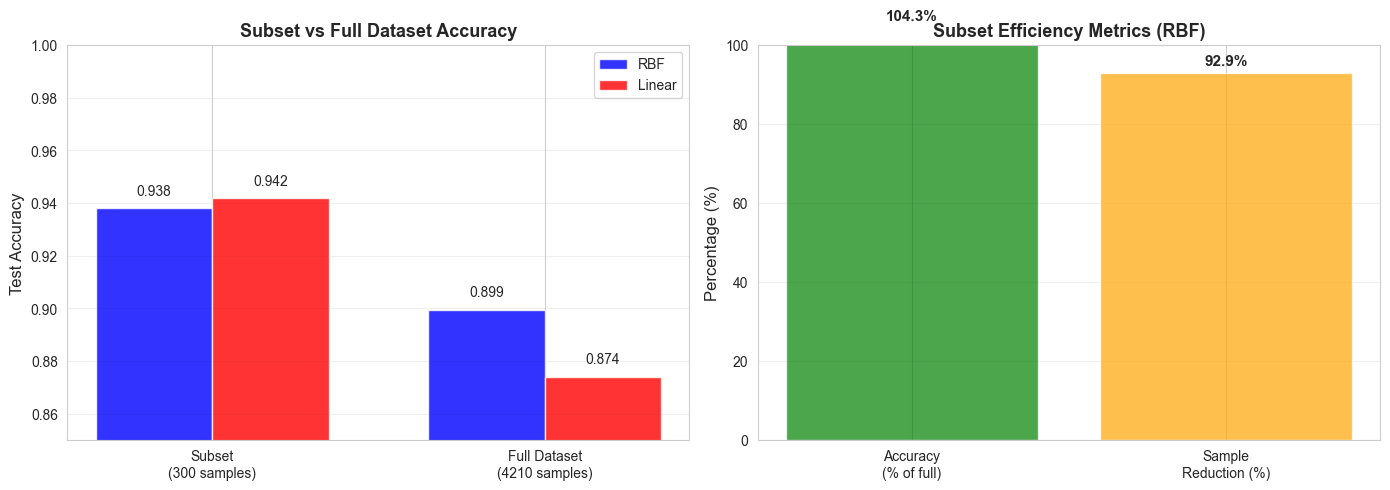

In [12]:
# ================================================================================
# CELL 10b: Visualization
# ================================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Accuracy comparison
categories = ['Subset\n(300 samples)', 'Full Dataset\n(4210 samples)']
rbf_accs = [best_subset_rbf['test_acc'], best_full_rbf['test_acc']]
linear_accs = [best_subset_linear['test_acc'], best_full_linear['test_acc']]

x = np.arange(len(categories))
width = 0.35

axes[0].bar(x - width/2, rbf_accs, width, label='RBF', color='blue', alpha=0.8)
axes[0].bar(x + width/2, linear_accs, width, label='Linear', color='red', alpha=0.8)
axes[0].set_ylabel('Test Accuracy', fontsize=12)
axes[0].set_title('Subset vs Full Dataset Accuracy', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(categories)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_ylim([0.85, 1.0])

# Add value labels on bars
for i, (rbf, lin) in enumerate(zip(rbf_accs, linear_accs)):
    axes[0].text(i - width/2, rbf + 0.005, f'{rbf:.3f}', ha='center', fontsize=10)
    axes[0].text(i + width/2, lin + 0.005, f'{lin:.3f}', ha='center', fontsize=10)

# Plot 2: Efficiency visualization
metrics = ['Accuracy\n(% of full)', 'Sample\nReduction (%)']
values = [efficiency, sample_reduction]
colors = ['green', 'orange']

axes[1].bar(metrics, values, color=colors, alpha=0.7)
axes[1].set_ylabel('Percentage (%)', fontsize=12)
axes[1].set_title('Subset Efficiency Metrics (RBF)', fontsize=13, fontweight='bold')
axes[1].set_ylim([0, 100])
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels
for i, v in enumerate(values):
    axes[1].text(i, v + 2, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()
